# 🧠 Stroke Risk Calculator

In [ ]:
# Cell 1: Install + imports
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

In [ ]:

# Cell 2: Load dataset
import kagglehub

path = kagglehub.dataset_download('mahatiratusher/stroke-risk-prediction-dataset-v2')
print('Downloaded to:', path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'Loaded: {len(df):,} rows | {df.shape[1]} columns')
display(df.head())


100%|██████████| 240k/240k [00:00<00:00, 58.5MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/mahatiratusher/stroke-risk-prediction-dataset-v2/versions/1
Loaded: 35,000 rows | 19 columns


,age,gender,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk
0,22,Male,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,33.3,0
1,52,Male,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,100.0,1
2,63,Female,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,100.0,1
3,41,Male,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,44.5,0
4,53,Male,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,84.8,1


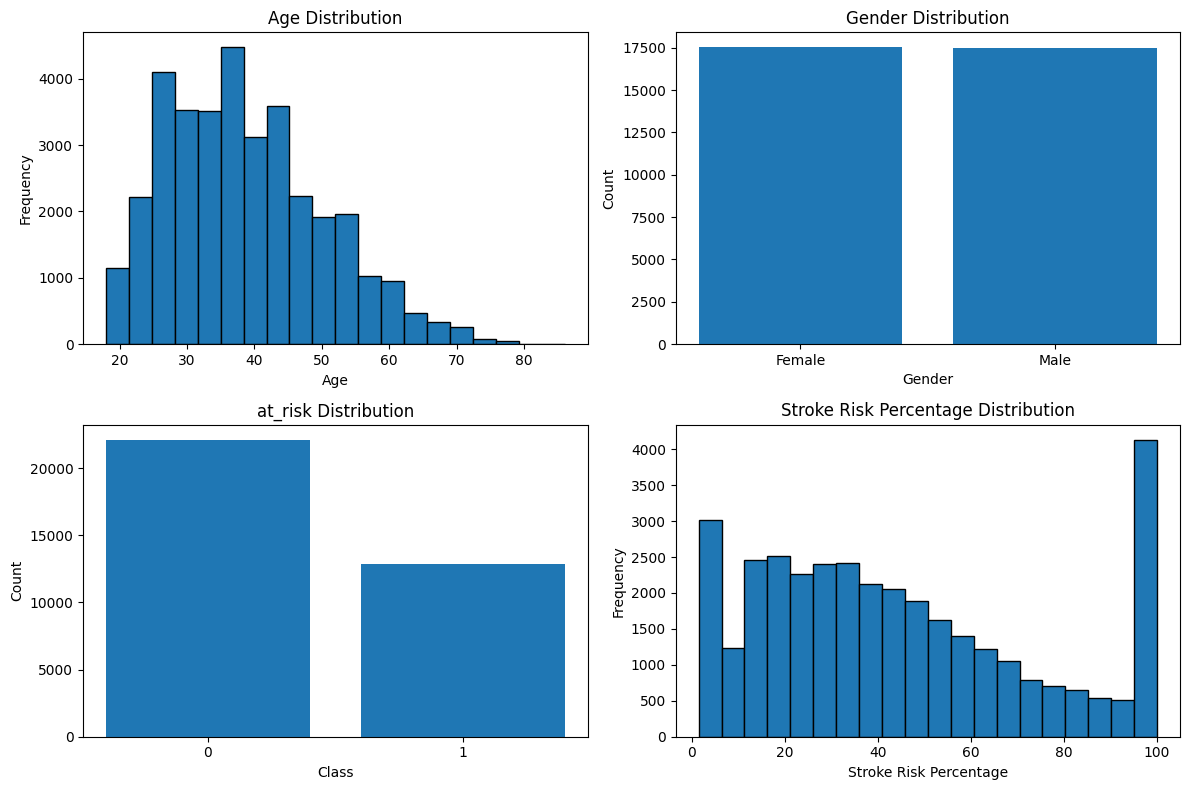

In [ ]:
# Cell 2: Simple dataset visualizations

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Age distribution
if 'age' in df.columns:
    axes[0, 0].hist(df['age'].dropna(), bins=20, edgecolor='black')
    axes[0, 0].set_title('Age Distribution')
    axes[0, 0].set_xlabel('Age')
    axes[0, 0].set_ylabel('Frequency')

# 2. Gender distribution
if 'gender' in df.columns:
    gender_counts = df['gender'].value_counts()
    axes[0, 1].bar(gender_counts.index.astype(str), gender_counts.values)
    axes[0, 1].set_title('Gender Distribution')
    axes[0, 1].set_xlabel('Gender')
    axes[0, 1].set_ylabel('Count')

# 3. Target distribution
if 'at_risk' in df.columns:
    risk_counts = df['at_risk'].value_counts().sort_index()
    axes[1, 0].bar(risk_counts.index.astype(str), risk_counts.values)
    axes[1, 0].set_title('at_risk Distribution')
    axes[1, 0].set_xlabel('Class')
    axes[1, 0].set_ylabel('Count')

# 4. Stroke risk percentage distribution
if 'stroke_risk_percentage' in df.columns:
    axes[1, 1].hist(df['stroke_risk_percentage'].dropna(), bins=20, edgecolor='black')
    axes[1, 1].set_title('Stroke Risk Percentage Distribution')
    axes[1, 1].set_xlabel('Stroke Risk Percentage')
    axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
# Cell 3: Quick audit + define target/features
print("Columns:")
print(df.columns.tolist())

print("\nMissing values per column:")
display(df.isna().sum().to_frame('missing_values').T)

if 'at_risk' not in df.columns:
    raise ValueError("The dataset must contain an 'at_risk' column.")

y = df['at_risk'].astype(int)

# Drop targets / leakage columns from features
leakage_cols = [c for c in ['at_risk', 'stroke_risk_percentage'] if c in df.columns]
X = df.drop(columns=leakage_cols).copy()

print("\nTarget distribution (at_risk):")
display(y.value_counts().rename_axis('class').to_frame('count'))
print(f"Positive rate: {y.mean():.3f}")

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print(f"\nFeature matrix shape: {X.shape}")

Columns:
['age', 'gender', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating', 'persistent_cough', 'nausea_vomiting', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom', 'stroke_risk_percentage', 'at_risk']

Missing values per column:


,age,gender,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Target distribution (at_risk):


,count
class,
0,22113
1,12887


Positive rate: 0.368

Categorical columns: ['gender']
Numeric columns: ['age', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating', 'persistent_cough', 'nausea_vomiting', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom']

Feature matrix shape: (35000, 17)


In [ ]:

# Cell 4: Train/test split + preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', encoder)
])

preprocess_scaled = ColumnTransformer(
    transformers=[
        ('num', numeric_scaled, numeric_cols),
        ('cat', categorical_pipe, categorical_cols),
    ],
    remainder='drop'
)

preprocess_unscaled = ColumnTransformer(
    transformers=[
        ('num', numeric_unscaled, numeric_cols),
        ('cat', categorical_pipe, categorical_cols),
    ],
    remainder='drop'
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (28000, 17)
Test shape : (7000, 17)


In [ ]:

# Cell 5: Define the five classifiers
models = {
    'Decision Tree': Pipeline(steps=[
        ('preprocess', preprocess_unscaled),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6, min_samples_leaf=20))
    ]),
    'KNN': Pipeline(steps=[
        ('preprocess', preprocess_scaled),
        ('model', KNeighborsClassifier(n_neighbors=11))
    ]),
    'SVM': Pipeline(steps=[
        ('preprocess', preprocess_scaled),
        ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
    ]),
    'Naive Bayes': Pipeline(steps=[
        ('preprocess', preprocess_scaled),
        ('model', GaussianNB())
    ]),
    'Logistic Regression': Pipeline(steps=[
        ('preprocess', preprocess_scaled),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
}

list(models.keys())


['Decision Tree', 'KNN', 'SVM', 'Naive Bayes', 'Logistic Regression']

In [ ]:

# Cell 6: Train, evaluate, and compare all classifiers

def evaluate_classifier(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, 'predict_proba'):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline, 'decision_function'):
        y_score = pipeline.decision_function(X_test)
    else:
        y_score = y_pred

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score),
    }

    return metrics, y_pred, y_score, pipeline

results = []
predictions = {}
trained_models = {}

for name, pipe in models.items():
    metrics, y_pred, y_score, fitted = evaluate_classifier(name, pipe, X_train, X_test, y_train, y_test)
    results.append(metrics)
    predictions[name] = {'y_pred': y_pred, 'y_score': y_score}
    trained_models[name] = fitted

results_df = pd.DataFrame(results).sort_values(
    by=['roc_auc', 'f1', 'accuracy'], ascending=False
).reset_index(drop=True)

results_df.index = np.arange(1, len(results_df) + 1)
results_df.insert(0, 'rank', results_df.index)
display(results_df.style.format({
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}',
    'roc_auc': '{:.4f}',
}))

best_model_name = results_df.iloc[0]['model']
print(f"Best overall model (ranked by ROC-AUC, then F1, then Accuracy): {best_model_name}")


,rank,model,accuracy,precision,recall,f1,roc_auc
1,1,SVM,0.9879,0.9826,0.9845,0.9835,0.9995
2,2,Logistic Regression,0.9796,0.9688,0.9759,0.9724,0.9984
3,3,KNN,0.9263,0.9332,0.8615,0.8959,0.9850
4,4,Naive Bayes,0.8869,0.7972,0.9290,0.8581,0.9645
5,5,Decision Tree,0.8947,0.9163,0.7858,0.8460,0.9547


Best overall model (ranked by ROC-AUC, then F1, then Accuracy): SVM


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1,
        error_score='raise'
    )
    cv_rows.append({
        'model': name,
        'cv_accuracy_mean': scores['test_accuracy'].mean(),
        'cv_precision_mean': scores['test_precision'].mean(),
        'cv_recall_mean': scores['test_recall'].mean(),
        'cv_f1_mean': scores['test_f1'].mean(),
        'cv_roc_auc_mean': scores['test_roc_auc'].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values(
    by=['cv_roc_auc_mean', 'cv_f1_mean', 'cv_accuracy_mean'], ascending=False
).reset_index(drop=True)

display(cv_df.style.format({c: '{:.4f}' for c in cv_df.columns if c != 'model'}))

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
0,SVM,0.9879,0.9842,0.9830,0.9836,0.9995
1,Logistic Regression,0.9811,0.9746,0.9739,0.9743,0.9985
2,KNN,0.9244,0.9351,0.8539,0.8926,0.9844
3,Naive Bayes,0.8906,0.8023,0.9328,0.8626,0.9678
4,Decision Tree,0.8894,0.9148,0.7715,0.8370,0.9516


In [ ]:

# Cell 8: Merge holdout and cross-validation results into one summary table
summary_df = results_df.merge(cv_df, on='model', how='left')
summary_df = summary_df.sort_values(
    by=['roc_auc', 'f1', 'accuracy'], ascending=False
).reset_index(drop=True)
summary_df.index = np.arange(1, len(summary_df) + 1)
summary_df['rank'] = summary_df.index

cols = [
    'rank', 'model',
    'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
    'cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_roc_auc_mean'
]
summary_df = summary_df[cols]

display(summary_df.style.format({c: '{:.4f}' for c in summary_df.columns if c not in ['rank', 'model']}))


,rank,model,accuracy,precision,recall,f1,roc_auc,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
1,1,SVM,0.9879,0.9826,0.9845,0.9835,0.9995,0.9879,0.9842,0.9830,0.9836,0.9995
2,2,Logistic Regression,0.9796,0.9688,0.9759,0.9724,0.9984,0.9811,0.9746,0.9739,0.9743,0.9985
3,3,KNN,0.9263,0.9332,0.8615,0.8959,0.9850,0.9244,0.9351,0.8539,0.8926,0.9844
4,4,Naive Bayes,0.8869,0.7972,0.9290,0.8581,0.9645,0.8906,0.8023,0.9328,0.8626,0.9678
5,5,Decision Tree,0.8947,0.9163,0.7858,0.8460,0.9547,0.8894,0.9148,0.7715,0.8370,0.9516


<Figure size 800x600 with 0 Axes>

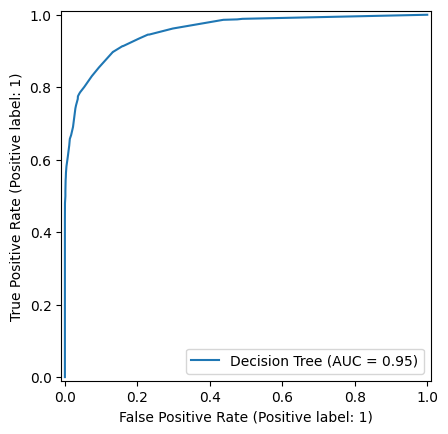

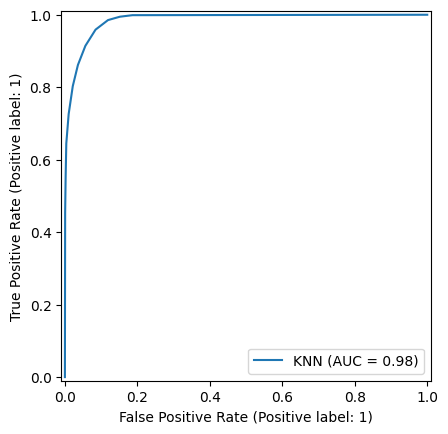

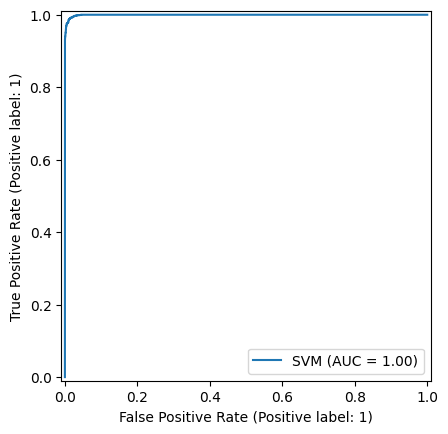

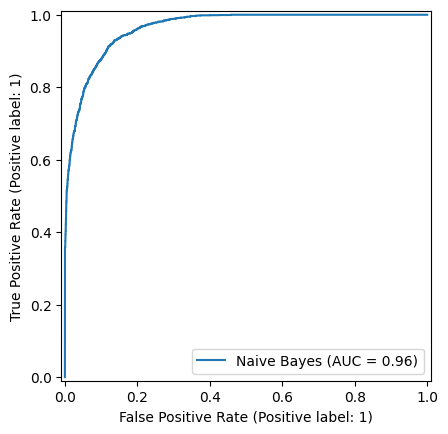

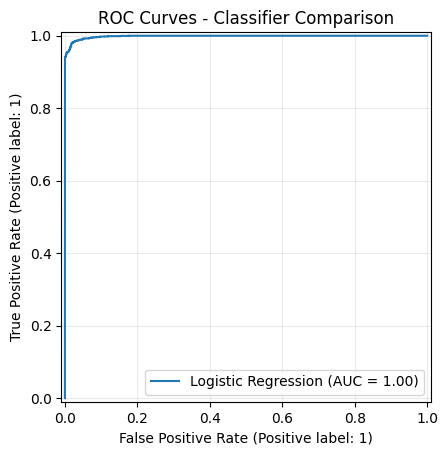

In [ ]:

# Cell 9: ROC curves
plt.figure(figsize=(8, 6))
for name, fitted in trained_models.items():
    if hasattr(fitted, 'predict_proba'):
        y_score = fitted.predict_proba(X_test)[:, 1]
    elif hasattr(fitted, 'decision_function'):
        y_score = fitted.decision_function(X_test)
    else:
        continue
    RocCurveDisplay.from_predictions(y_test, y_score, name=name)

plt.title('ROC Curves - Classifier Comparison')
plt.grid(alpha=0.25)
plt.show()


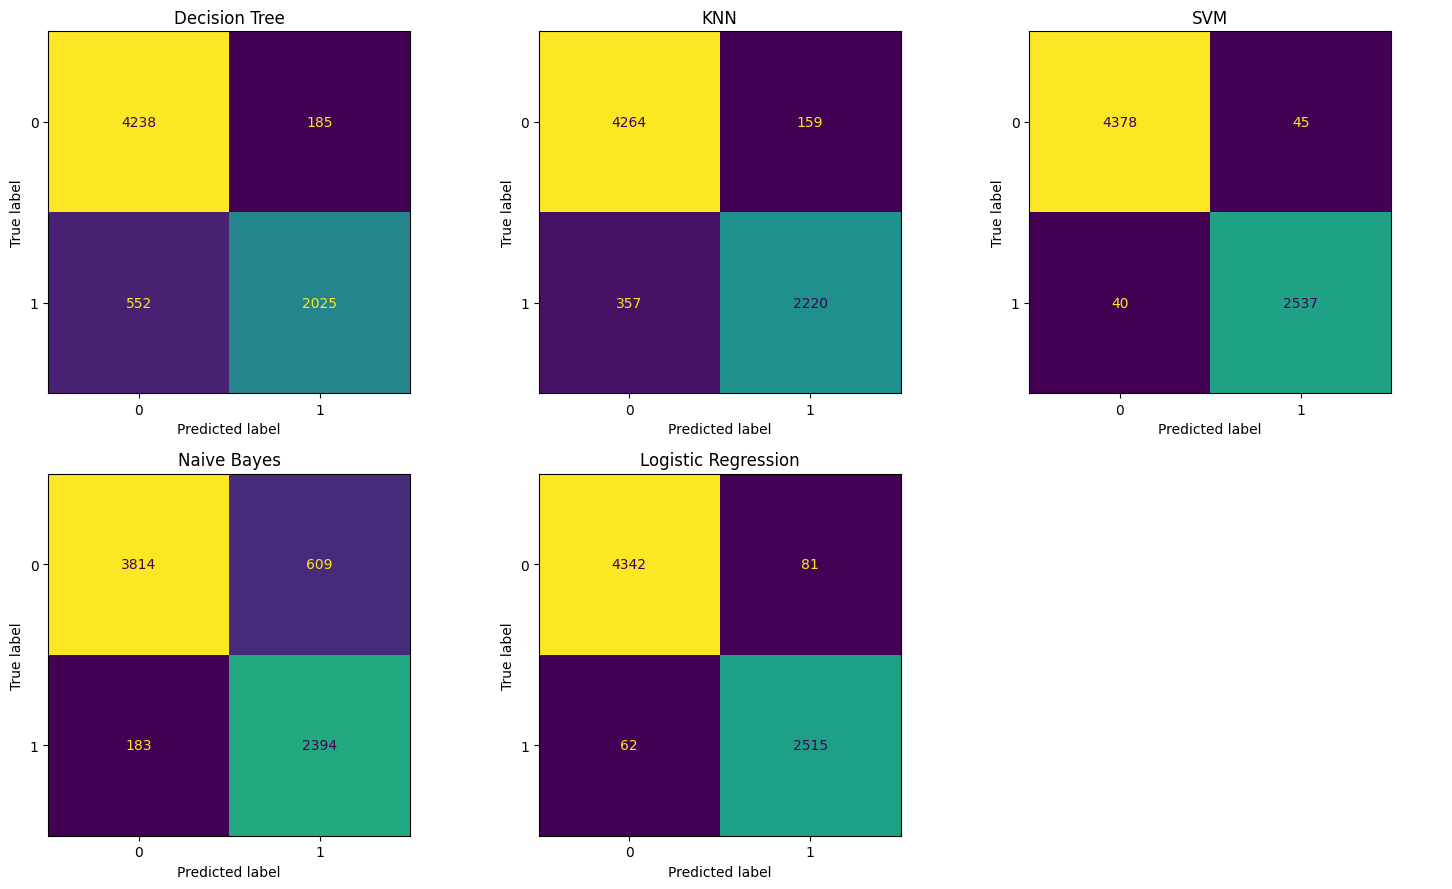

In [ ]:

# Cell 10: Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, pred_obj) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred_obj['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

# Hide the last empty subplot because we only have 5 models
for ax in axes[len(predictions):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:

# Cell 11: Classification reports
for name, pred_obj in predictions.items():
    print('=' * 80)
    print(name)
    print(classification_report(y_test, pred_obj['y_pred'], digits=4))


Decision Tree
              precision    recall  f1-score   support

           0     0.8848    0.9582    0.9200      4423
           1     0.9163    0.7858    0.8460      2577

    accuracy                         0.8947      7000
   macro avg     0.9005    0.8720    0.8830      7000
weighted avg     0.8964    0.8947    0.8928      7000

KNN
              precision    recall  f1-score   support

           0     0.9227    0.9641    0.9429      4423
           1     0.9332    0.8615    0.8959      2577

    accuracy                         0.9263      7000
   macro avg     0.9280    0.9128    0.9194      7000
weighted avg     0.9266    0.9263    0.9256      7000

SVM
              precision    recall  f1-score   support

           0     0.9909    0.9898    0.9904      4423
           1     0.9826    0.9845    0.9835      2577

    accuracy                         0.9879      7000
   macro avg     0.9868    0.9872    0.9870      7000
weighted avg     0.9879    0.9879    0.9879      700

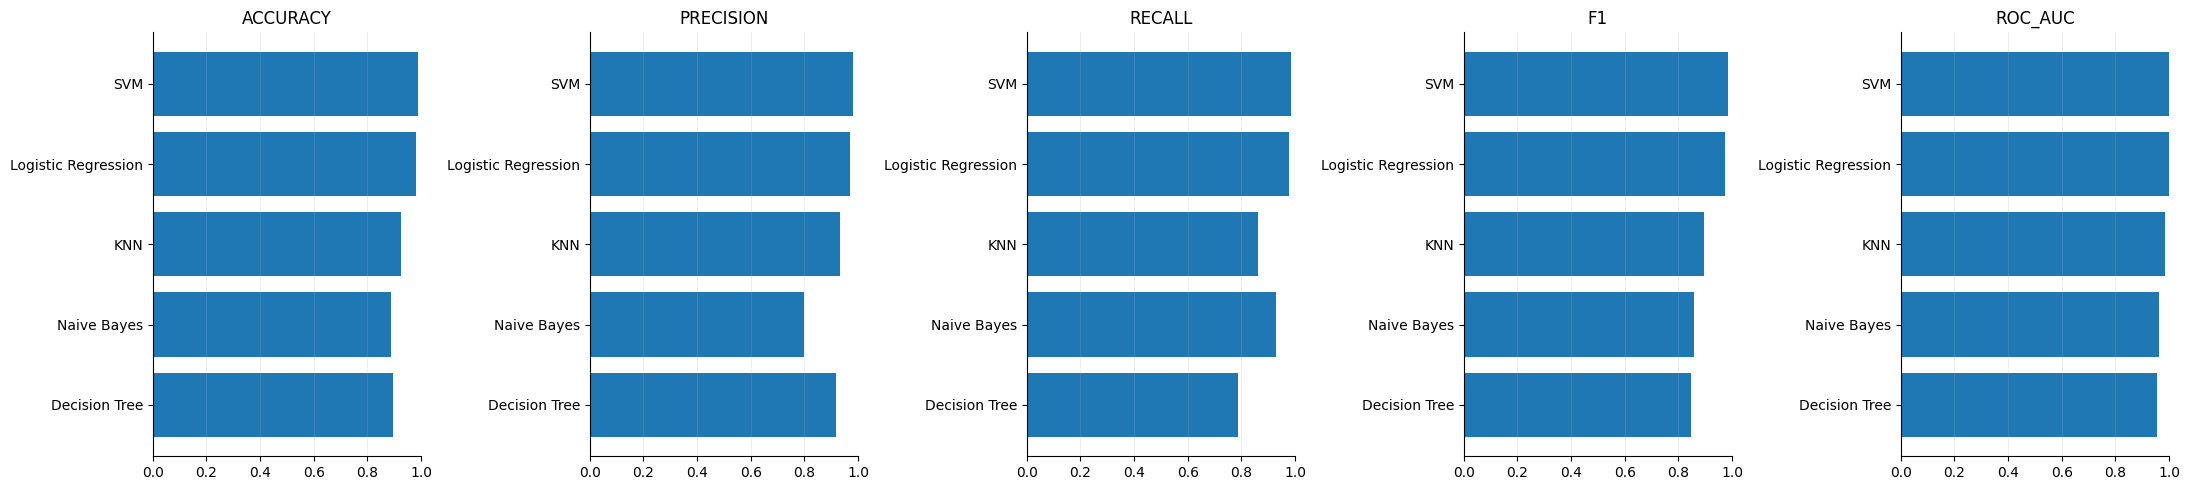

In [ ]:

# Cell 12: Metric comparison charts
plot_df = results_df.sort_values('roc_auc', ascending=True)
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 5))
for ax, metric in zip(axes, metrics_to_plot):
    ax.barh(plot_df['model'], plot_df[metric])
    ax.set_title(metric.upper())
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:

# Cell 13: Best model recap
best_row = summary_df.iloc[0]

print('Best model summary')
print('-' * 60)
print(f"Model     : {best_row['model']}")
print(f"Accuracy  : {best_row['accuracy']:.4f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"F1 Score  : {best_row['f1']:.4f}")
print(f"ROC-AUC   : {best_row['roc_auc']:.4f}")
print(f"CV F1     : {best_row['cv_f1_mean']:.4f}")
print(f"CV ROC-AUC: {best_row['cv_roc_auc_mean']:.4f}")


Best model summary
------------------------------------------------------------
Model     : SVM
Accuracy  : 0.9879
Precision : 0.9826
Recall    : 0.9845
F1 Score  : 0.9835
ROC-AUC   : 0.9995
CV F1     : 0.9836
CV ROC-AUC: 0.9995


SVM works well when the classes can be separated by a strong boundary, especially with the RBF kernel, which can capture nonlinear patterns.This suggests the relationship between the input features and stroke risk is not purely linear, and the SVM was able to capture that pattern effectively.

The best-performing model in the project was the Support Vector Machine. It achieved an accuracy of 98.79%, precision of 98.26%, recall of 98.45%, and an F1-score of 98.35%, showing that it performed extremely well in both identifying at-risk individuals and minimizing false predictions. Its ROC-AUC was 0.9995, which indicates near-perfect separation between the two classes. The cross-validation results were almost identical, which suggests that the model’s performance is stable and consistent across multiple folds. Overall, this shows that the SVM was the most effective classifier for this dataset, although the results should still be interpreted carefully because the dataset is synthetic.

Columns being evaluated:
['chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating', 'persistent_cough', 'nausea_vomiting', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom']

Best model used: SVM


,symptom,baseline_mean_probability,mean_prob_when_off,mean_prob_when_on,mean_delta_probability,abs_mean_delta,median_delta_probability,std_delta_probability,max_increase,max_decrease,direction,weight_percent
0,chest_pain,0.3694,0.3300,0.5770,0.2470,0.2470,0.0000,0.4065,1.0000,0.0000,increases risk,12.32%
1,high_blood_pressure,0.3694,0.3054,0.5433,0.2378,0.2378,0.0000,0.4016,1.0000,0.0000,increases risk,11.86%
2,snoring_sleep_apnea,0.3694,0.3418,0.5190,0.1772,0.1772,0.0000,0.3538,1.0000,0.0000,increases risk,8.84%
3,irregular_heartbeat,0.3694,0.3523,0.5274,0.1751,0.1751,0.0000,0.3510,1.0000,0.0000,increases risk,8.73%
4,shortness_of_breath,0.3694,0.3347,0.5074,0.1727,0.1727,0.0000,0.3498,1.0000,0.0000,increases risk,8.61%
5,chest_discomfort,0.3694,0.3457,0.5183,0.1725,0.1725,0.0000,0.3502,1.0000,0.0000,increases risk,8.61%
6,persistent_cough,0.3694,0.3574,0.4714,0.1140,0.1140,0.0000,0.2831,0.9999,-0.0000,increases risk,5.69%
7,fatigue_weakness,0.3694,0.3397,0.4526,0.1129,0.1129,0.0000,0.2839,1.0000,0.0000,increases risk,5.63%
8,neck_jaw_pain,0.3694,0.3592,0.4713,0.1121,0.1121,0.0000,0.2797,1.0000,-0.0000,increases risk,5.59%
9,dizziness,0.3694,0.3470,0.4575,0.1104,0.1104,0.0000,0.2798,1.0000,0.0000,increases risk,5.51%


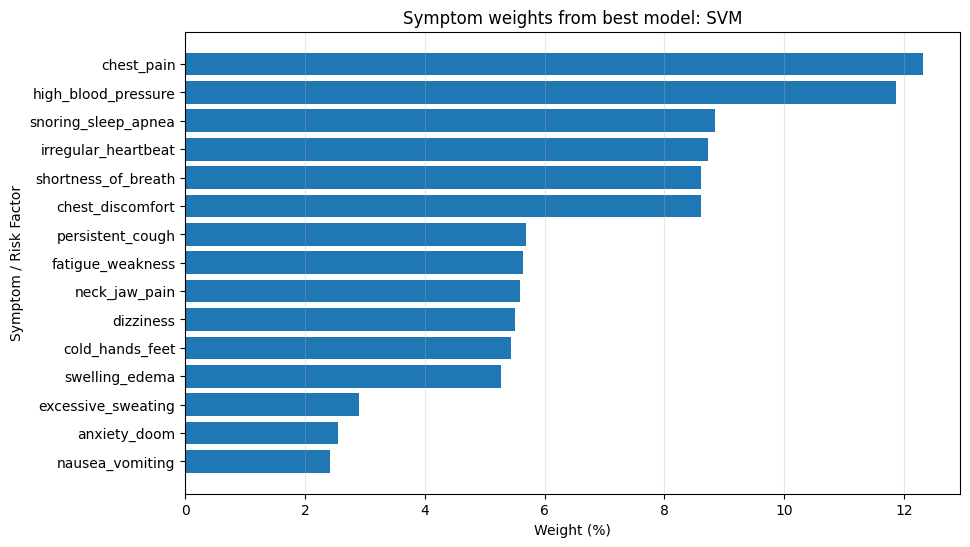

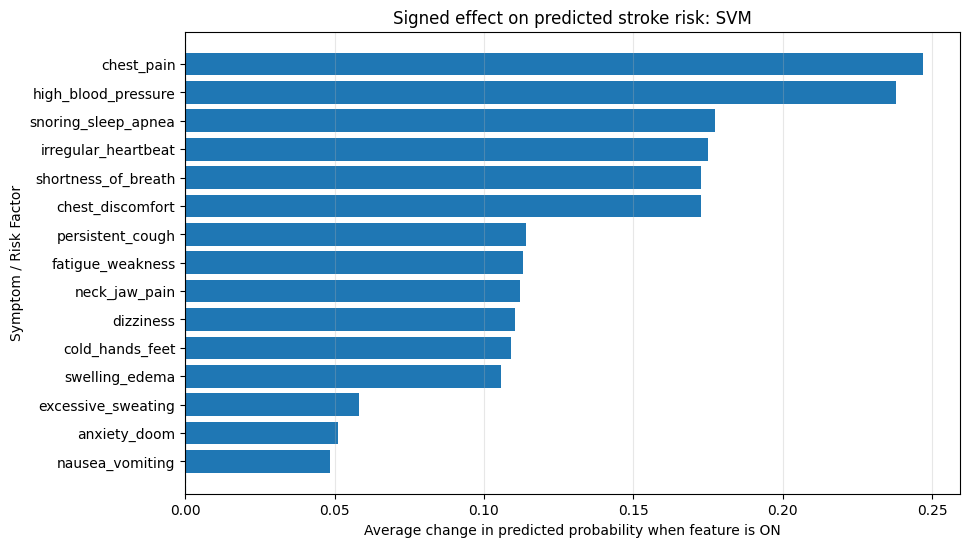


Symptom weights dictionary:
{'chest_pain': 12.32, 'high_blood_pressure': 11.86, 'snoring_sleep_apnea': 8.84, 'irregular_heartbeat': 8.73, 'shortness_of_breath': 8.61, 'chest_discomfort': 8.61, 'persistent_cough': 5.69, 'fatigue_weakness': 5.63, 'neck_jaw_pain': 5.59, 'dizziness': 5.51, 'cold_hands_feet': 5.44, 'swelling_edema': 5.28, 'excessive_sweating': 2.91, 'anxiety_doom': 2.56, 'nausea_vomiting': 2.42}


In [ ]:
# Cell: Exact model-based symptom/risk-factor weights using your dataset columns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# 1) Get best trained model and data
# -----------------------------------
best_pipeline = trained_models[best_model_name]
X_explain = X_test.copy()

# -----------------------------------
# 2) Exact columns to evaluate
# -----------------------------------
symptom_cols = [
    'chest_pain',
    'high_blood_pressure',
    'irregular_heartbeat',
    'shortness_of_breath',
    'fatigue_weakness',
    'dizziness',
    'swelling_edema',
    'neck_jaw_pain',
    'excessive_sweating',
    'persistent_cough',
    'nausea_vomiting',
    'chest_discomfort',
    'cold_hands_feet',
    'snoring_sleep_apnea',
    'anxiety_doom'
]

# Keep only columns that actually exist in X_test
symptom_cols = [col for col in symptom_cols if col in X_explain.columns]

print("Columns being evaluated:")
print(symptom_cols)

if len(symptom_cols) == 0:
    raise ValueError("None of the listed symptom columns were found in X_test.")

# -----------------------------------
# 3) Helper: positive-class probability
# -----------------------------------
def get_positive_prob(model, X_input):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_input)
        scores = np.asarray(scores, dtype=float)
        if scores.max() == scores.min():
            return np.full_like(scores, 0.5, dtype=float)
        return (scores - scores.min()) / (scores.max() - scores.min())
    else:
        return model.predict(X_input).astype(float)

# -----------------------------------
# 4) Toggle each symptom from OFF to ON
# -----------------------------------
rows = []
base_prob = get_positive_prob(best_pipeline, X_explain)

for col in symptom_cols:
    X_off = X_explain.copy()
    X_on = X_explain.copy()

    # Since these are binary features in your dataset:
    X_off[col] = 0
    X_on[col] = 1

    prob_off = get_positive_prob(best_pipeline, X_off)
    prob_on = get_positive_prob(best_pipeline, X_on)

    delta = prob_on - prob_off

    rows.append({
        'symptom': col,
        'baseline_mean_probability': float(np.mean(base_prob)),
        'mean_prob_when_off': float(np.mean(prob_off)),
        'mean_prob_when_on': float(np.mean(prob_on)),
        'mean_delta_probability': float(np.mean(delta)),
        'abs_mean_delta': float(np.mean(np.abs(delta))),
        'median_delta_probability': float(np.median(delta)),
        'std_delta_probability': float(np.std(delta)),
        'max_increase': float(np.max(delta)),
        'max_decrease': float(np.min(delta))
    })

symptom_weight_df = pd.DataFrame(rows)

# -----------------------------------
# 5) Interpret direction
# -----------------------------------
symptom_weight_df['direction'] = np.where(
    symptom_weight_df['mean_delta_probability'] > 1e-6,
    'increases risk',
    np.where(
        symptom_weight_df['mean_delta_probability'] < -1e-6,
        'decreases risk',
        'no clear effect'
    )
)

# -----------------------------------
# 6) Give EVERY symptom a weight
# -----------------------------------
total_abs = symptom_weight_df['abs_mean_delta'].sum()

if total_abs == 0:
    symptom_weight_df['weight_percent'] = 100 / len(symptom_weight_df)
else:
    symptom_weight_df['weight_percent'] = (
        symptom_weight_df['abs_mean_delta'] / total_abs
    ) * 100

symptom_weight_df = symptom_weight_df.sort_values(
    by='weight_percent',
    ascending=False
).reset_index(drop=True)

# -----------------------------------
# 7) Display results
# -----------------------------------
print(f"\nBest model used: {best_model_name}")

display(
    symptom_weight_df.style.format({
        'baseline_mean_probability': '{:.4f}',
        'mean_prob_when_off': '{:.4f}',
        'mean_prob_when_on': '{:.4f}',
        'mean_delta_probability': '{:.4f}',
        'abs_mean_delta': '{:.4f}',
        'median_delta_probability': '{:.4f}',
        'std_delta_probability': '{:.4f}',
        'max_increase': '{:.4f}',
        'max_decrease': '{:.4f}',
        'weight_percent': '{:.2f}%'
    })
)

# -----------------------------------
# 8) Plot: weight percentages
# -----------------------------------
plot_df = symptom_weight_df.sort_values('weight_percent', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['symptom'], plot_df['weight_percent'])
plt.xlabel('Weight (%)')
plt.ylabel('Symptom / Risk Factor')
plt.title(f'Symptom weights from best model: {best_model_name}')
plt.grid(axis='x', alpha=0.3)
plt.show()

# -----------------------------------
# 9) Plot: signed effect
# -----------------------------------
plot_signed = symptom_weight_df.sort_values('mean_delta_probability', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_signed['symptom'], plot_signed['mean_delta_probability'])
plt.xlabel('Average change in predicted probability when feature is ON')
plt.ylabel('Symptom / Risk Factor')
plt.title(f'Signed effect on predicted stroke risk: {best_model_name}')
plt.axvline(0, linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.show()

# -----------------------------------
# 10) Optional dictionary for reuse
# -----------------------------------
symptom_weights_dict = dict(
    zip(symptom_weight_df['symptom'], symptom_weight_df['weight_percent'].round(2))
)

print("\nSymptom weights dictionary:")
print(symptom_weights_dict)

This table shows how the best model’s predicted stroke-risk probability changes when each symptom or risk factor is switched from absent to present. The ‘mean_prob_when_off’ and ‘mean_prob_when_on’ columns show the average prediction in each case. The ‘mean_delta_probability’ shows whether the feature raises or lowers risk, and the ‘weight_percent’ shows how important that feature is relative to the others.

When high blood pressure is switched from absent to present, the model’s average predicted stroke-risk probability increases by 29 percentage points. This makes it one of the strongest contributors in the model, with a relative importance weight of 17.5%